**N_grams and neural bigrams from scratch as well as Nano-GPT via pytorch**

side note: the code was run in a seperate py file, as it was easier to handle long training times

In [1]:
# Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import copy
import datetime
import matplotlib.pyplot as plt
import numpy as np
import time


import re
from collections import Counter
import os


A method to print strings into a file with filename

In [2]:
def log_message(message, filename):
    with open(filename, "a") as f:
        f.write(message + "\n")

#dataset preprocessing methods 

In [3]:
def read_file_from (corpus_segment: str, file_subfolder: str, k: int = 2000):

    if file_subfolder.lower() == "corpus": 
        file_path = f"Corpus/Shakespeare_clean_{corpus_segment}.txt"
    elif file_subfolder.lower() == "learned_vocabularies":
        file_path = f"Learned_vocabularies/bpe_vocabulary_of_{corpus_segment}_set_with_k_{k}.txt"
    else:
        file_path = f"Tokenized_corpus/tokenized_{corpus_segment}_set_with_k_{k}.txt"
    
    try:
        with open(file_path , "r") as input_file:
            raw_text = input_file.read()
    except FileNotFoundError:
        parent_direcory = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
        alternative_file_path = os.path.join(parent_direcory, file_path)
        with open(alternative_file_path, "r") as input_file:
            raw_text = input_file.read()

    if file_subfolder.lower() == "corpus": 
        return raw_text
    else:
        tokenized_text = raw_text.split("\n")
        if tokenized_text[-1] == "":
            tokenized_text.pop()
    
        return tokenized_text
   

def get_charred_word_type_corpus_representation (corpus: str):

    #this one tells how frequent each word type is in the corpus
    non_tokenized_word_type_frequencies = count_token_frequencies_of(tokenize_naively(corpus.lower()))

    #this one also tells how frequent each word type is in the corpus
    #the difference is that here each word type is stored as
    #an array of chars at this stage of the program
    #later those chars will be merged into subword tokens
    tokenized_word_type_frequencies = {}

    for i in non_tokenized_word_type_frequencies:
        tokens_of_a_word_type = get_string_chars(i)
        tokens_of_a_word_type.append("</w>")
        tokenized_word_type_frequencies[tuple(tokens_of_a_word_type)] = non_tokenized_word_type_frequencies[i]
    
    return tokenized_word_type_frequencies


def count_token_frequencies_of(unique_tokens: list):
    return Counter(unique_tokens)

#space-based tokenization
def tokenize_naively(corpus: str):
    return re.findall(r"[A-Za-z]+", corpus)


def get_string_chars(string: str):
    return re.findall(r"[A-Za-z]", string)

class Token_Translator:
    def __init__(self, vocab: list):
        self.symbol_to_index = {symbol:index for index, symbol in enumerate(vocab)}
        self.index_to_symbol = {index:symbol for index, symbol in enumerate(vocab)}

    def encode_list(self, list_to_encode: list):
        return [self.symbol_to_index[i] for i in list_to_encode]
    
    def decode_list(self, list_to_decode):
        result = []
        for i in list_to_decode:
            # if i is a torch tensor, extract its value
            #if isinstance(i, torch.Tensor):
            #    i = i.item()   # now a Python int
            result.append(self.index_to_symbol[i])
        return result

Printing most frequent words in a corpus. I opted for printing the length of the list of all word tokens and of all word types in the full corpus rather than those lists themselves not to clutter the notebook. You can see UNIX shell results in the project subfolder unix_shell_results.

In [4]:
import nltk
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

#with open("shakespeare.txt", "r", encoding="utf-8") as f:
#    text = f.read()
#print(text)

text = read_file_from("full", "corpus")

print (text[0:9])

text_words = text.lower().split()


print (text_words[0:9])

unique_words = set()
unique_words_count = dict()


for word in text_words:
    #unique_words.add(word)

    if not word.isnumeric():
        word_lemma = lemmatizer.lemmatize(word)
        unique_words.add(word_lemma)
        if not word_lemma in unique_words_count.keys():
            unique_words_count[word_lemma] = 1
        else:
            unique_words_count[word_lemma] += 1

print ("all words", len(text_words))
print ("unique words", len(unique_words))
#print (len(unique_words_count))
#print ("most frequent words: ", unique_words_count[0:9])

sorted_dict = dict(sorted(unique_words_count.items(), key=lambda item: item[1], reverse=True))

print("Most frequent items: ", list(sorted_dict.items())[:30])

The Trage
['the', 'tragedy', 'of', 'antony', 'and', 'cleopatra', 'dramatis', 'personae', 'mark']
all words 190999
unique words 22166
Most frequent items:  [('the', 6202), ('and', 5362), ('i', 4219), ('a', 4163), ('to', 4007), ('of', 3422), ('my', 2554), ('in', 2264), ('you', 2235), ('that', 2171), ('is', 2025), ('not', 1679), ('with', 1618), ('it', 1481), ('for', 1447), ('his', 1352), ('be', 1324), ('he', 1283), ('but', 1269), ('this', 1262), ('your', 1239), ('have', 1231), ('me', 1119), ('thou', 1046), ('will', 964), ('what', 916), ('do', 896), ('so', 813), ('shall', 792), ('by', 744)]


BPE token learner which has sublinear computational complexity w. r. t. corpus size measured by the number of word tokens. I presented this token learner in class. You find a detailed description of the trick to decrease computational complexity thereof in the token learner section of the project report.

In [5]:
def write_tokens(tokens: list, n_iter: int, corpus_segment: str, token_gen_duration: float):

    # 1) figure out parent directory
    cwd       = os.getcwd()
    #parent    = os.path.abspath(os.path.join(cwd, os.pardir))

    # 2) build (and create) your output folder under the parent
    #out_dir   = os.path.join(parent, "Learned_vocabularies")

    out_dir = os.path.join(cwd, "Learned_vocabularies")
    os.makedirs(out_dir, exist_ok=True)

    # 3) build your file name and full path
    file_name = f"bpe_vocabulary_of_{corpus_segment}_set_with_k_{n_iter}.txt"
    file_path = os.path.join(out_dir, file_name)

    # 4) write out your tokens
    with open(file_path, "w", encoding="utf-8") as out_f:
        for token in tokens:
            out_f.write(f"{token}\n")
    print(f"Wrote {len(tokens)} tokens to {file_path}")


def bpe (vocab: list, corpus_representation: dict, n_iter: int, corpus_segment: str):
    start = time.time()
    for current_iter in range(n_iter):

        inter_word_counter = {}
        for word_type, word_type_frequency in corpus_representation.items():

            #how often a token pair occurs in a word type
            intra_word_counter = Counter(zip(word_type, word_type[1:]))
            
            for key in intra_word_counter:

                #how often a token occurs in a word type * word type frequency in a corpus
                intermediate_key_frequency = intra_word_counter[key] * word_type_frequency

                #add intermediate key frequency across word types
                #in which in occurs
                if not key in inter_word_counter:
                    inter_word_counter[key] = intermediate_key_frequency
                else:
                    inter_word_counter[key] += intermediate_key_frequency
       
        #new token to append is the token with the highest
        #interword frequency i.e. with the highest occurence 
        #frequency in a corpus
        new_token_tuple = max(inter_word_counter, key=inter_word_counter.get)
        new_token_element1 = new_token_tuple[0]
        new_token_element2 = new_token_tuple[1]
        new_token = new_token_element1 + new_token_element2
        #print ("new token ", new_token)
        if not new_token in vocab:
            vocab.append(new_token)
        else:
            print ("!!!NON-UNIQUE TOKEN GENERATION ATTEMPT\n")

        #replace pairs of new_token_element1, new_token_element2
        #with new_token_element1 + new_token_element2
        #in all word types of a corpus
        new_corpus_representation = {}
        for word_type, word_type_frequency in corpus_representation.items():
       
            new_word_type = []
            i = 0
            while i < len(word_type):
                if word_type[i] == new_token_element1 and word_type[i+1] == new_token_element2:
                    new_word_type.append(new_token)
                    i += 2
                else:
                    new_word_type.append(word_type[i])
                    i += 1
      
            new_corpus_representation[tuple(new_word_type)] = word_type_frequency 
        corpus_representation = new_corpus_representation

        #save learned vocabularies in learned_vocabularies subfolder
        if (current_iter+1) >= 400 and (current_iter+1) % 200 == 0:
            end = time.time()
            elapsed = end - start
            write_tokens(vocab, current_iter+1, corpus_segment, elapsed)
    
    return vocab

#!!!
#DO NOT change the value of this variable
#token learner should only learn tokens on training set
CORPUS_SEGMENT = "train"

#read raw text of the training corpus
raw_text = read_file_from(CORPUS_SEGMENT, "corpus")

#get a list of letters of the case-folded corpus
corpus_chars = get_string_chars(raw_text.lower())

#the initial vocabulary is a list of unique letters of the case folded corpus
vocabulary = list(set(corpus_chars))
#add special end-of-word token to the initial vocabulary
vocabulary.append("</w>")

#get a hash map corpus representation with word types as keys and their frequencies as values
#word types are represented as tuples of subword tokens from the vocavulary
tokenized_word_type_frequencies = get_charred_word_type_corpus_representation(raw_text)


start = time.time()
#run bpe
#bpe would save vocabularies of sizes from 427 to 2027
#in the project subfolder Learned_vocabularies
vocab = bpe(vocabulary, tokenized_word_type_frequencies, 2000, CORPUS_SEGMENT)
end = time.time()
elapsed = end - start
print(f"Elapsed time: {elapsed:.4f} seconds")


Wrote 427 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_400.txt
Wrote 627 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_600.txt
Wrote 827 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_800.txt
Wrote 1027 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_1000.txt
Wrote 1227 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_1200.txt
Wrote 1427 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_1400.txt
Wrote 1627 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_1600.txt
Wrote 1827 tokens to D:\Python_projects\CL\GPT from Scratch\Learned_vocabularies\bpe_vocabulary_of_train_set_with_k_1800.txt
Wrote 

BPE text segmentor using vocabularies learned by the token learner. BPE text segmentor uses a trick very similar to the one of the token learner. More on that in the text segmentor section of the project report.

In [6]:
#write segmentation results into
#subfolder Tokenized_corpus
def write_tokenized_corpus_segment (corpus_chunk_name: str, segmented_corpus_chunk: list, k: int):
    file_path = f"Tokenized_corpus/Tokenized_{corpus_chunk_name}_set_with_k_{k}.txt"
    try:
        with open(file_path, "w") as output_file:
            for token in segmented_corpus:
                output_file.write(f"{token}\n")
    except FileNotFoundError:
        parent_direcory = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
        alternative_file_path = os.path.join(parent_direcory, file_path)
        with open(alternative_file_path, "w") as output_file:
            for token in segmented_corpus_chunk:
                output_file.write(f"{token}\n")
    print (f"{corpus_chunk_name} set is segmented via vocab with k = {k}")

#get the efficient corpus representation
#i.e. a hash map with word types as keys
#and whole word token positions in the original corpus as values
def get_word_type_counts_with_positions_in_a_corpus (corpus: str):
    corpus_tokens = tokenize_naively(corpus.lower())


    corpus_representation: dict[tuple, list] = {} 
    for word_token_index, word_token in enumerate(corpus_tokens):

        
        word_token_charred = get_string_chars(word_token)
        
        word_token_charred.append("</w>")
        #print (word_token_charred)
        #print (type(word_token_charred) )
        word_token_chars = tuple(word_token_charred)
        
        if not word_token_chars in corpus_representation:
            corpus_representation[word_token_chars] = [word_token_index]
        else:
            corpus_representation[word_token_chars].append(word_token_index)
    return corpus_representation, len(corpus_tokens)


#merges contiguous chars of word types of the corpus
#into entries of a learned vocabulary used to 
#segment a corpus
def merge_corpus_chars (corpus_representation: dict, vocab: list):

    for vocab_item in vocab:
    
        if len(vocab_item) > 1 and vocab_item != "</w>":

            new_corpus_representation: dict [tuple, list] = {}
            
            for word_type, word_type_positions in corpus_representation.items():
                new_word_type = []
                i = 0
                while i < len (word_type):
                    if (i< len (word_type)-1) and (word_type[i]+word_type[i+1] == vocab_item):
                        new_word_type.append(vocab_item)
                        i += 2
                    else:
                        new_word_type.append(word_type[i])
                        i += 1
                new_corpus_representation [tuple(new_word_type)] = word_type_positions 
            corpus_representation = new_corpus_representation    
    return corpus_representation

#reconstruct the original form of the corpus from
#its efficient representation, i.e. a hash map with word types as keys
#and whole word token positions in the original corpus as values
def reconstruct_corpus_from (corpus_representation: dict, n_words_in_corpus: int):

    reconstructed_corpus = [0] * n_words_in_corpus

    for word_type, word_type_positions_in_corpus in corpus_representation.items():
        for word_type_position in word_type_positions_in_corpus:
            reconstructed_corpus[word_type_position] = word_type 

    #return reconstructed_corpus
    return [x for tup in reconstructed_corpus for x in tup]

def tokenize_sequence(corpus: str, vocabulary: list):
    charred_word_types_with_frequencies_and_positions, number_of_words_in_a_corpus = get_word_type_counts_with_positions_in_a_corpus (corpus)
    corpus_tokens_compressed = merge_corpus_chars(charred_word_types_with_frequencies_and_positions, vocabulary)
    reconstructed_corpus = reconstruct_corpus_from(corpus_tokens_compressed, number_of_words_in_a_corpus)
    return reconstructed_corpus

#!!!
#YOU NEED to change the value of K and CORPUS_SEGMENT MANUALLY
#so that the text segmentor segments the part of the corpus you want to segment (train, valid, test)
#with the vocabulary of your choosing 
#although there are vocabularies with K=400 to 2000 with the step of 2000 in the learner_vocabularies subfolder
#language models below only use K=400, 1200 and/or 2000
K = 1200
CORPUS_SEGMENT = "train"
raw_corpus = read_file_from(CORPUS_SEGMENT, "corpus")
vocabulary = read_file_from("train", "Learned_vocabularies", K)


segmented_corpus = tokenize_sequence (raw_corpus, vocabulary)
write_tokenized_corpus_segment (CORPUS_SEGMENT, segmented_corpus, K)

#if this is successful, you get a file with CORPUS_SEGMENT and K in the name 
#in the subfolder Tokenized_Corpus

train set is segmented via vocab with k = 1200


This is an n_gram model with sublinear next token generation complexity. More on that in the n_gram section of the project report. 

For vocab size k = 400 and n = 1 perplexity on test set is equal to 273.525461665404
For vocab size k = 400 and n = 2 perplexity on test set is equal to 65.28843678212252
For vocab size k = 400 and n = 3 perplexity on test set is equal to 31.190104388046727
For vocab size k = 400 and n = 4 perplexity on test set is equal to 26.174094530236857
For vocab size k = 400 and n = 5 perplexity on test set is equal to 25.551443053667914
For vocab size k = 400 and n = 6 perplexity on test set is equal to 25.395850589805324
For vocab size k = 400 and n = 7 perplexity on test set is equal to 25.365654656643517
For vocab size k = 400 and n = 8 perplexity on test set is equal to 25.367908735710174
For vocab size k = 400 and n = 9 perplexity on test set is equal to 25.36048177125493
For vocab size k = 400 and n = 10 perplexity on test set is equal to 25.361189074675057
Generated sequence now is:  true king is dfor and rolonius i did enact julius caesar i was killed i the capitol brutus killed me haml

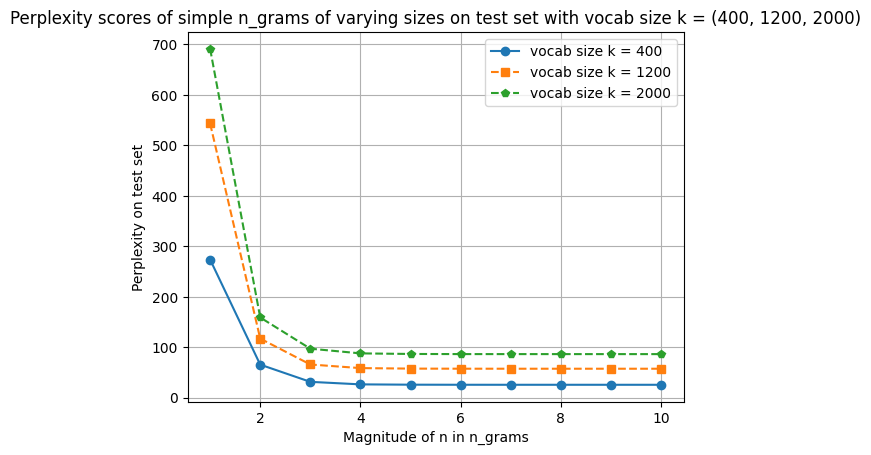

In [7]:
def get_n_gram_counts_from(n: int, corpus_tokens: list):
    # Build n sliding iterators over the token list
    n_gram_iterators = [corpus_tokens[i:] for i in range(n)]
    # Zip to produce n-gram tuples from these slices
    n_grams = zip(*n_gram_iterators)
    return Counter(n_grams)

#get all n_gram from n_gram_counts whose frequency exceeds a threshold
def get_frequent_n_grams (n_gram_counts: Counter, frequency_threshold: int):
    return {key: value for key, value in n_gram_counts.items() if value > frequency_threshold}

#get n_gram counts as well as those n_grams sorted in the descending order
#by the number of times those n_grams occur in the corpus
def get_n_grams_infos_from (n: int, corpus_tokens: list):
    counts_of_n_grams = get_n_gram_counts_from(n, corpus_tokens)
    #remove singleton n_grams from n_gram list
    #counts_of_n_grams = get_frequent_n_grams(counts_of_n_grams, 1)
    sorted_n_grams = sorted(counts_of_n_grams)
    return counts_of_n_grams, sorted_n_grams  

#get the position of the FIRST n_gram which starts with a given prefix
#in a list of n_grams sorted in the descending order
#by the number of times those n_grams occur in the corpus
#via binary search
def get_leftmost_index_of_in (n_gram_prefix: tuple, n_gram_list: list):

    n = len(n_gram_prefix)
    left_bound = 0
    right_bound = len(n_gram_list) - 1

    result = -1
    
    while left_bound <= right_bound:
        
        mid = (right_bound + left_bound) // 2

        if n_gram_list[mid][:n] >= n_gram_prefix:
            result = mid
            right_bound = mid - 1
        else:
            left_bound = mid + 1

    return result

#get the position of the LAST n_gram which starts with a given prefix
#in a list of n_grams sorted in the descending order
#by the number of times those n_grams occur in the corpus
#via binary search
def get_rightmost_index_of_in (n_gram_prefix: tuple, n_gram_list: list):

    n = len(n_gram_prefix)
    left_bound = 0
    right_bound = len(n_gram_list) - 1
    result = -1
    
    while left_bound <= right_bound:
        mid = (right_bound + left_bound) // 2
      
        if n_gram_list[mid][:n] <= n_gram_prefix:
            left_bound = mid + 1
            result = mid
        else:
            right_bound = mid - 1

    return result

#use backoff to generate the next token in a given sequence
def get_next_most_probable_token_after_via_backoff(sequence: list, 
                                                   sorted_n_grams: list, 
                                                   n_gram_counts: list
                                                ):

    next_token_found = False
    for i in range(0, len(sorted_n_grams)):

        left_index = get_leftmost_index_of_in(sequence[i:], sorted_n_grams[i])
        right_index = get_rightmost_index_of_in(sequence[i:], sorted_n_grams[i])

        if left_index > -1 and right_index > -1 and right_index >= left_index:

            #print (sorted_n_grams[left_index:(right_index+1)])

            max_frequency, n_gram_with_max_frequency = 0, ()
            for most_frequent_n_gram_candidate in sorted_n_grams[i][left_index:(right_index+1)]:

                #print (most_frequent_n_gram_candidate, n_gram_counts[most_frequent_n_gram_candidate])

                if n_gram_counts[i][most_frequent_n_gram_candidate] > max_frequency:
                    max_frequency = n_gram_counts[i][most_frequent_n_gram_candidate]
                    n_gram_with_max_frequency = most_frequent_n_gram_candidate
            
            next_token = n_gram_with_max_frequency[len(n_gram_with_max_frequency)-1]
            next_token_found = True
            break

    if not next_token_found:
        next_token = "or</w>"

    return next_token

#get perplexity of backoff
def get_perplexity_score_of_via(corpus_segment: str, 
                                n_gram_counts: list, 
                                max_n_gram_len: int, 
                                k: int = 2000,
                                backoff_discounter: float = 0.75
                            ):

    corpus_tokens = read_file_from (corpus_segment, "tokenized_corpus", k)
    total_number_of_unigrams = sum(n_gram_counts[-1].values())
    net_log_P = 0

    for i in range (max_n_gram_len - 1, len (corpus_tokens)-1):
        sequence = tuple(corpus_tokens[i- max_n_gram_len + 1 : i+1])
        n_gram_found = False
        for j in range(max_n_gram_len):
            
            sequence_freq = n_gram_counts[j][sequence[j:]]
         
            if sequence_freq > 0:
             
                #we have not backed off to a unigram yet, because
                #length (current n_gram without the last element) > 0 
                if len (sequence[j:-1]) > 0:
                    perplexity_divisor = n_gram_counts[j+1][sequence[j:-1]]
                    #current_log_P = (sequence_freq - backoff_discounter) / perplexity_divisor 

                #we have backed off to a unigram when the
                #length (current n_gram without the last element) = 0 
                else:
                    perplexity_divisor = total_number_of_unigrams
                    #current_log_P = sequence_freq / perplexity_divisor 
                
                #penalized_perplexity_numerator = max(1e-5, sequence_freq - backoff_discounter*(j+1))
                #current_log_P = penalized_perplexity_numerator / perplexity_divisor 
                current_log_P = (sequence_freq - backoff_discounter) / perplexity_divisor 
         
                net_log_P += math.log(current_log_P) 

                n_gram_found = True
                break
        if not n_gram_found:
            print ("NO N_GRAM FOUND FOR: ", sequence[j:])
    len_corpus = len (corpus_tokens) - max_n_gram_len
    perplexity = math.exp(-1* net_log_P / len_corpus)
 
    return perplexity

def plot_perplexity (perplexity_scores1: list, perplexity_scores2: list, perplexity_scores3: list, k1:int, k2: int, k3:int):
    # Indices
    #indices1 = range(len(perplexity_scores_K_2000))  
    indices1 = np.arange(len(perplexity_scores1)) + 1
    indices2 = np.arange(len(perplexity_scores2)) + 1
    indices3 = np.arange(len(perplexity_scores3)) + 1

    #indices2 = range(len(val_loss_history)) 

    # Plot both
    plt.plot(indices1, perplexity_scores1, marker='o', linestyle='-', label=f'vocab size k = {k1}')
    plt.plot(indices2, perplexity_scores2, marker='s', linestyle='--', label=f'vocab size k = {k2}')
    plt.plot(indices3, perplexity_scores3, marker='p', linestyle='--', label=f'vocab size k = {k3}')

    plt.xlabel('Magnitude of n in n_grams')
    plt.ylabel('Perplexity on test set')
    plt.title(f'Perplexity scores of simple n_grams of varying sizes on test set with vocab size k = {k1, k2, k3}')
    plt.legend()
    plt.grid(True)

    plt.savefig(f"Perplexity_scores_of_simple_n_grams.png", dpi=300, bbox_inches='tight')

    plt.show()


def go_into_generation_mode (k: int):
    vocabulary = read_file_from("train", "Learned_vocabularies", k)
    while True:
        #input_string = input("Give me 3 words separated by single spaces to autocomplete: ")
        input_string = "true king is"
        #input_string_tokens = tokenize_sequence(input_string)
        input_string_tokens = tokenize_sequence(input_string, vocabulary)
        
        for _ in range(200):
            input_string_tail_tokens = tuple(input_string_tokens[-(MAX_N_GRAM_LENGTH-1):])
            next_token = get_next_most_probable_token_after_via_backoff(input_string_tail_tokens, sorted_n_grams, counts_of_n_grams)
            input_string_tokens.append(next_token)
        
        gen_sequence = "".join(input_string_tokens).replace("</w>"," ")

        print ("Generated sequence now is: ", gen_sequence)

        filename = "simple_n_gram_gen_text.txt"
        log_message(f"vocab size k = {k}, generated sequence is:\n{gen_sequence}", filename)
        log_message("_" * 100, filename)

        break
    

    
MAX_N_GRAM_LENGTH = 10

K = 400
corpus_tokens = read_file_from("train", "tokenized_corpus", K)
counts_of_n_grams, sorted_n_grams = [], []
for i in range (MAX_N_GRAM_LENGTH, 0, -1):
    counts_of_i_grams, sorted_i_grams = get_n_grams_infos_from(i, corpus_tokens)
    counts_of_n_grams.append(counts_of_i_grams)
    sorted_n_grams.append(sorted_i_grams)

evaluation_set = "test"
perplexity_scores_K_400 = []
for i in range(1, MAX_N_GRAM_LENGTH + 1):
    perplexity = get_perplexity_score_of_via (evaluation_set, counts_of_n_grams[-i:], i, K)
    perplexity_scores_K_400.append(perplexity)
    print (f"For vocab size k = {K} and n = {i} perplexity on {evaluation_set} set is equal to {perplexity}")
go_into_generation_mode (K)

K = 1200
corpus_tokens = read_file_from("train", "tokenized_corpus", K)
counts_of_n_grams, sorted_n_grams = [], []
for i in range (MAX_N_GRAM_LENGTH, 0, -1):
    counts_of_i_grams, sorted_i_grams = get_n_grams_infos_from(i, corpus_tokens)
    counts_of_n_grams.append(counts_of_i_grams)
    sorted_n_grams.append(sorted_i_grams)

evaluation_set = "test"
perplexity_scores_K_1200 = []
for i in range(1, MAX_N_GRAM_LENGTH + 1):
    perplexity = get_perplexity_score_of_via (evaluation_set, counts_of_n_grams[-i:], i, K)
    perplexity_scores_K_1200.append(perplexity)
    print (f"For vocab size k = {K} and n = {i} perplexity on {evaluation_set} set is equal to {perplexity}")
go_into_generation_mode (K)


K = 2000
corpus_tokens = read_file_from("train", "tokenized_corpus", K)
counts_of_n_grams, sorted_n_grams = [], []
for i in range (MAX_N_GRAM_LENGTH, 0, -1):
    counts_of_i_grams, sorted_i_grams = get_n_grams_infos_from(i, corpus_tokens)
    counts_of_n_grams.append(counts_of_i_grams)
    sorted_n_grams.append(sorted_i_grams)

evaluation_set = "test"
perplexity_scores_K_2000 = []
for i in range(1, MAX_N_GRAM_LENGTH + 1):
    perplexity = get_perplexity_score_of_via (evaluation_set, counts_of_n_grams[-i:], i)
    perplexity_scores_K_2000.append(perplexity)
    print (f"For vocab size k = {K} and n = {i} perplexity on {evaluation_set} set is equal to {perplexity}")
go_into_generation_mode (K)

plot_perplexity (perplexity_scores_K_400, perplexity_scores_K_1200, perplexity_scores_K_2000, 400, 1200, 2000)



"Neural" bigrams optimized via stochastic gradient descent and RMSprop. No hyperparameter tuninig was required for the numpy version of neural bigrams. I just picked vocab size K = 400, since it was the more successful one for n_grams.

BPE k = 400
learning rate = 0.5
learning rate decay per epoch = 0.95
n_epochs = 15
__________________________________________________
Epoch 1/15
current avg RMSprop learning rate = 6564.3525390625
average train loss is 4.467706680297852
average val loss = 3.63877
__________________________________________________
Epoch 2/15
current avg RMSprop learning rate = 6955.2451171875
average train loss is 3.1115000247955322
average val loss = 2.86266
__________________________________________________
Epoch 3/15
current avg RMSprop learning rate = 6990.0478515625
average train loss is 2.603397846221924
average val loss = 2.46963
__________________________________________________
Epoch 4/15
current avg RMSprop learning rate = 7006.91064453125
average train loss is 2.3381495475769043
average val loss = 2.26093
__________________________________________________
Epoch 5/15
current avg RMSprop learning rate = 7018.556640625
average train loss is 2.1691153049468994
average val loss = 2.11574
_________

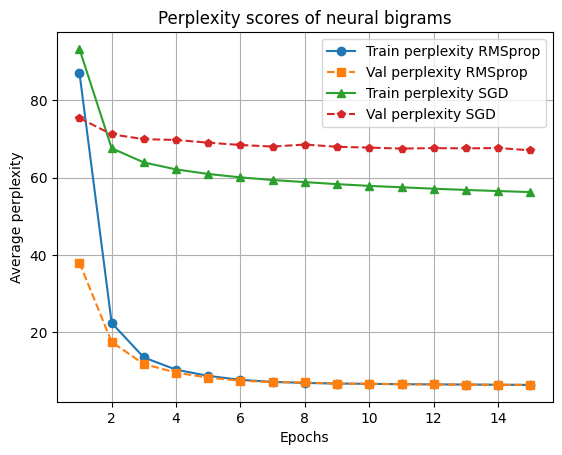

In [8]:
from utilities import read_file_from, log_message, Token_Translator
import numpy as np
import random
import copy
import matplotlib.pyplot as plt



class Neural_n_gram_model:

    def __init__(self, vocabulary_size: int):
        rng = np.random.default_rng(seed=42)  
        np_table = rng.normal(
            loc=0.0,          # mean
            scale=0.2,        # standard deviation
            size=(vocabulary_size, vocabulary_size)
        ).astype(np.float32)
        #np_table = 0,3 * rng.standard_normal((vocabulary_size, vocabulary_size)).astype(np.float32)
        #self.token_embedding_table = torch.from_numpy(np_table).requires_grad_()
        self.token_embedding_table = np_table


    #cross entropy is computed over unnormalized logits
    #only logit of the target class needs to be normalized
    #to compute cross entropy of the respective prediction
    def _get_cross_entropy (self, logits, target_index):
        softmax_denominator = np.sum(np.exp(logits)) + 1e-8
        return -logits[target_index] + np.log(softmax_denominator)
    
    def _get_normalized_logits(self, logits):
        softmax_denominator = np.sum(np.exp(logits))
        return np.exp(logits) / softmax_denominator
    
    def _get_normalized_logits_with_softmax_denom(self, logits):
        softmax_denominator = np.sum(np.exp(logits))
        return np.exp(logits) / softmax_denominator, softmax_denominator
    
    def forward(self, token_idx: int, target_index: int=None):
   
        logits = self.token_embedding_table[token_idx]
        #if the model is in the inference mode
        #just return the logits since
        #argumentum maximi of those is sufficient
        #to determine the next likeliest token 
        if target_index is None:  
            return logits
        
        #if the model is in training mode
        #just return the cross-entropy loss gradient
        #to accelerate gradient descent
        else:
            #CEL_gradient = self._get_normalized_logits(logits)
            normalized_logits, softmax_denom = self._get_normalized_logits_with_softmax_denom(logits)

            CEL_value = -logits[target_index] + np.log(softmax_denom)

            normalized_logits[target_index] -= 1
            CEL_gradient = normalized_logits

            #predicted_true_class_probability = normalized_logits[target_index] 
            #CEL_value = -np.log(predicted_true_class_probability)
            
            return CEL_value, CEL_gradient

   
    
    def generate_new_tokens(self, token_sequence: list, n_tokens: int, k_for_top_k:int = 3):
        for _ in range (n_tokens):
            last_token_index = token_sequence[-1]
          
            #next_token_index = np.argmax(self.token_embedding_table[last_token_index])
         
            #get the list of k likeliest next tokens
            topk = np.argpartition(self.token_embedding_table[last_token_index], -k_for_top_k)[-k_for_top_k:]

            #sample one token from k likeliest ones uniformly
            random_index = np.random.randint(0, k_for_top_k)  
            next_token_index = topk[random_index]

            token_sequence.append(next_token_index)
        return token_sequence
    
def evaluate_model_on(model, dataset):
    total_loss = 0
    for x, y in dataset:
        total_loss += model.forward(x, y)[0]
    return total_loss/len(dataset)


def train_model_with (model: Neural_n_gram_model, 
                         optimizer: str, 
                         lr: float, 
                         n_epochs: int, 
                         train_set,
                         val_set,
                         rho: float = 0.9,
                         sgd_lr_multiplier: float = 0.95
                        ):
    #token_pairs = list(zip(preceding_tokens, subsequent_tokens))
    train_loss_history = []
    val_loss_history = []

    best_avg_epoch_loss = 1000

    if optimizer.lower() == "rmsprop":
        RMSprop_running_square_gradient_avg = np.zeros_like(neural_n_gram_model_RMSprop.token_embedding_table)

    for epoch_index in range(1, n_epochs + 1):

        print (f"Epoch {epoch_index}/{n_epochs}")

        
        if optimizer.lower() == "rmsprop": 
            total_RMS_prop_lr = 0.0
        else:
            print (f"current SGD learning rate = {lr}")

        
        total_loss = 0
       
        
        #random.shuffle(token_pairs)
        random.shuffle(train_set) 
      
        #for x,y in token_pairs:
        for x,y in train_set:

            #get the CEL gradient from the forward pass directly
            loss, loss_gradient = model.forward(x, y)
            


            #compute running gradient avg for RMSprop
            #and do gradient descent step 
            if optimizer.lower() == "rmsprop":  
                RMSprop_running_square_gradient_avg[x] *=  rho
                RMSprop_running_square_gradient_avg[x] += (loss_gradient ** 2) * (1-rho)
                RMSprop_denominator = np.sqrt(RMSprop_running_square_gradient_avg[x] + 0.1e-6)
                current_lr = lr / RMSprop_denominator
                total_RMS_prop_lr += current_lr.mean()
                model.token_embedding_table[x] -=  current_lr * loss_gradient
            else:

            #just do gradient descent step for SGD
                model.token_embedding_table[x] -= lr*loss_gradient

        

            total_loss += loss
          
        if optimizer.lower() == "rmsprop":
            total_RMS_prop_lr /= len(preceding_tokens)
            print (f"current avg RMSprop learning rate = {total_RMS_prop_lr}")
        else:
            lr *= sgd_lr_multiplier
        
        

        #total_loss /= len(preceding_tokens)
        total_loss /= len(train_set)
        print (f"average train loss is {total_loss}")
        train_loss_history.append(total_loss)

        avg_val_loss = evaluate_model_on (model, val_set)
        print (f"average val loss = {avg_val_loss:.5f}")
        #log_message (f"average val loss = {avg_val_loss:.5f}")
        val_loss_history.append(avg_val_loss)

        if avg_val_loss < best_avg_epoch_loss:
            best_avg_epoch_loss = avg_val_loss
            best_model = copy.deepcopy(model)

        print ("_" * 50)

    if best_model is not None:
        return best_model, train_loss_history, val_loss_history
    else:
        return model, train_loss_history, val_loss_history
    #return model, train_loss_history, val_loss_history


def plot_perplexity (train_perplexity_scores1: list, 
                     val_perplexity_scores1: list, 
                     train_perplexity_scores2: list, 
                     val_perplexity_scores2: list, 
                     ):
    # Indices
    #indices1 = range(len(perplexity_scores_K_2000))  
    indices1 = np.arange(len(train_perplexity_scores1)) + 1
    indices2 = np.arange(len(val_perplexity_scores1)) + 1
    indices3 = np.arange(len(train_perplexity_scores2)) + 1
    indices4 = np.arange(len(val_perplexity_scores2)) + 1


    #indices2 = range(len(val_loss_history)) 

    # Plot both
    plt.plot(indices1, train_perplexity_scores1, marker='o', linestyle='-', label=f'Train perplexity RMSprop')
    plt.plot(indices2, val_perplexity_scores1, marker='s', linestyle='--', label=f'Val perplexity RMSprop')
    plt.plot(indices3, train_perplexity_scores2, marker='^', linestyle='-', label=f'Train perplexity SGD')
    plt.plot(indices4, val_perplexity_scores2, marker='p', linestyle='--', label=f'Val perplexity SGD')
  
    plt.xlabel('Epochs')
    plt.ylabel('Average perplexity')
    plt.title(f'Perplexity scores of neural bigrams')
    plt.legend()
    plt.grid(True)

    plt.savefig(f"Perplexity_scores_of_neural_bigrams.png", dpi=300, bbox_inches='tight')

    plt.show()


K = 400


corpus_tokens = read_file_from("train", "tokenized_corpus", K)
vocabulary = read_file_from ("train", "learned_vocabularies", K)
vocabulary_size = len (vocabulary)

token_translator = Token_Translator(vocabulary)
encoded_tokens = token_translator.encode_list(corpus_tokens)
preceding_tokens = encoded_tokens[:-1]
subsequent_tokens = encoded_tokens[1:]



train_set_400 = list(zip(preceding_tokens, subsequent_tokens))

val_tokens = read_file_from("valid", "tokenized_corpus", K)
encoded_tokens = token_translator.encode_list(val_tokens)
preceding_tokens = encoded_tokens[:-1]
subsequent_tokens = encoded_tokens[1:]

val_set_400 = list(zip(preceding_tokens, subsequent_tokens))

test_tokens = read_file_from("test", "tokenized_corpus", K)
encoded_tokens = token_translator.encode_list(test_tokens)
preceding_tokens = encoded_tokens[:-1]
subsequent_tokens = encoded_tokens[1:]

test_set_400 = list(zip(preceding_tokens, subsequent_tokens))





neural_n_gram_model_SGD = Neural_n_gram_model(vocabulary_size)
neural_n_gram_model_RMSprop = Neural_n_gram_model(vocabulary_size)



SGD_LEARNING_RATE = 0.5
RMS_PROP_INITIAL_LR = 0.3
LEARNING_RATE_MULTIPLIER_PER_EPOCH = 0.95
N_EPOCHS = 15

#this hyperparameter is called "alpha" in pytorch
RMS_PROP_RHO = 0.9
#RMS_PROP_EPSILON = 0.1e-7



print (f"BPE k = {K}")
print (f"learning rate = {SGD_LEARNING_RATE}")
print (f"learning rate decay per epoch = {LEARNING_RATE_MULTIPLIER_PER_EPOCH}")
print (f"n_epochs = {N_EPOCHS}")
print ("_" * 50)




neural_n_gram_model_RMSprop, train_loss_history_RMSprop, val_loss_history_RMSprop = train_model_with (neural_n_gram_model_RMSprop,
                                                                      "RMSprop",
                                                                      RMS_PROP_INITIAL_LR,
                                                                      N_EPOCHS,
                                                                      train_set_400,
                                                                      val_set_400,
                                                                      RMS_PROP_RHO
                                                                      )


#print ("ASKJDHA", evaluate_model_on(neural_n_gram_model_RMSprop, val_set_400))

input_sequence_RMSprop = [78]
input_sequence_RMSprop = neural_n_gram_model_RMSprop.generate_new_tokens(input_sequence_RMSprop, 200)
decoded_input_sequence_RMSprop = token_translator.decode_list(input_sequence_RMSprop)
print ("RMSprop text")
RMS_text = "".join(decoded_input_sequence_RMSprop).replace("</w>", " ")
print (RMS_text)
print ("CEL", train_loss_history_RMSprop)
print ("PERP", np.exp(train_loss_history_RMSprop))
print ("_" * 50)



neural_n_gram_model_SGD, train_loss_history_SGD, val_loss_history_SGD = train_model_with (neural_n_gram_model_SGD,
                                                                      "SGD",
                                                                      SGD_LEARNING_RATE,
                                                                      N_EPOCHS,
                                                                      train_set_400,
                                                                      val_set_400,
                                                                      RMS_PROP_RHO,
                                                                      LEARNING_RATE_MULTIPLIER_PER_EPOCH
                                                                      )
    



input_sequence_SGD = [78]
input_sequence_SGD = neural_n_gram_model_SGD.generate_new_tokens(input_sequence_SGD, 200)
decoded_input_sequence_SGD = token_translator.decode_list(input_sequence_SGD)
print ("SGD text")
SGD_text = "".join(decoded_input_sequence_SGD).replace("</w>", " ")
print (SGD_text)
print (train_loss_history_SGD)
print ("_" * 50)




RMS_test_perp = np.exp(evaluate_model_on (neural_n_gram_model_RMSprop, test_set_400))
SGD_test_perp = np.exp(evaluate_model_on (neural_n_gram_model_SGD, test_set_400))
print (f"RMS test score = {RMS_test_perp}")
print (f"SGD test score = {SGD_test_perp}")


filename = "neural_bigram_test_set_perplexities.txt"

log_message (f"BPE k = {K}", filename)
log_message (f"n_epochs = {N_EPOCHS}", filename)
log_message ("_" * 100, filename)

log_message (f"RMSpror initial learning rate = {RMS_PROP_INITIAL_LR}", filename)
log_message (f"RMSprop rho = {RMS_PROP_RHO}", filename)

log_message(f"RMS test score = {RMS_test_perp}", filename)
log_message("_" * 50, filename)
log_message(f"RMS text = {RMS_text}", filename)
log_message("_"*75, filename)


log_message (f"SGD initial learning rate = {SGD_LEARNING_RATE}", filename)
log_message (f"SDG learning rate decay per epoch = {LEARNING_RATE_MULTIPLIER_PER_EPOCH}", filename)

log_message(f"SGD test score = {SGD_test_perp}", filename)
log_message("_" * 50, filename)
log_message(f"SGD text = {SGD_text}", filename)
log_message("_"*75, filename)

plot_perplexity (np.exp(train_loss_history_RMSprop), np.exp(val_loss_history_RMSprop), np.exp(train_loss_history_SGD), np.exp(val_loss_history_SGD))

this is nano_gpt with causal self-attention. The model is optimized using a similar optimizer as the one in neural bigrams: RMSprop with rho/alpha of 0.9 and epsilon of 1e-6. The difference between the two optimizers is that the GPT one is uses L2 weight decay regularization implemented in pytorch whereas the neural bigram is done via numpy and as such has no weight decay. 

initial search hyperparameters were {
    'vocab_size': K_values,
    'lr': [1e-3, 5e-3],
    'n_layers': [4, 8],
    'embed_dim': [8, 16, 32, 64, 128],
    'num_heads': [4],
    'max_context': [128]
} with K_values = [400, 1200, 2000]

Each hyperparam constellation has been tested for 5 epochs. No significant benefits have been found for 8 layers compared to 4. 

The above grid search has been completed. The results are in training_log_20250904_042540.txt. The terminated one also included smaller learning rates and n_layers of 16. No significant benefits for n_layers of 16 compared to 8 and 4 seen there as well, for vocab size of 400 at least. Detailed results are in training_log_20250903_220823.txt.

Based on the completed and the uncompleted grid search I conclude that n_layers of 4 is sufficient and that the embeding dimension of 8 and 16 is insufficient to yeild good results. It could however make sense to try learning rates smaller than 1e-3. 5e-4 is skipped to decrease the time the notebook is running. The learning rate of 5e-3 is useless. Hence the grid search hyperparameter values in the cell below. 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim



class Causal_self_Attention(nn.Module):
    def __init__(self, embed_size, num_heads=4):
        super(Causal_self_Attention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads
        if embed_size % num_heads != 0:
            raise AssertionError("Embedding size must be divisible by number of heads")

        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)

        self.out_proj = nn.Linear(embed_size, embed_size)

        self.register_buffer("mask", None, persistent=False)

    def forward(self, x):
        batch_size, seq_len, embed_size = x.size()

        if self.mask is None or self.mask.size(0) != seq_len:
            mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
            self.register_buffer("mask", mask, persistent=False)
       

        Q_proj = self.query(x)
        K_proj = self.key(x)
        V_proj = self.value(x)

        Q_heads = Q_proj.reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        K_heads = K_proj.reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        V_heads = V_proj.reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        attn_scores = torch.einsum('bhqd,bhkd->bhqk', Q_heads, K_heads) / math.sqrt(self.head_dim)
        attn_scores = attn_scores.masked_fill(self.mask, float('-inf'))

        attn_prob = F.softmax(attn_scores, dim=-1)

        weighted_value = torch.einsum('bhqk,bhkd->bhqd', attn_prob, V_heads)

        concat = weighted_value.permute(0, 2, 1, 3).contiguous().reshape(batch_size, seq_len, embed_size)

        output = self.out_proj(concat)

        return output


class Feed_Forward(nn.Module):
    def __init__(self, embed_size, hidden_size=None):
        super(Feed_Forward, self).__init__()
        hidden_size = hidden_size or 4 * embed_size
        self.fc1 = nn.Linear(embed_size, hidden_size)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, embed_size)

    def forward(self, x):
        intermediate = self.fc1(x)
        activated = self.gelu(intermediate)
        output = self.fc2(activated)
        return output


class Transformer_Block(nn.Module):
    def __init__(self, embed_size, num_heads):
        super(Transformer_Block, self).__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.self_attention = Causal_self_Attention(embed_size, num_heads)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = Feed_Forward(embed_size)

    def forward(self, x):
        x_normed1 = self.norm1(x)
        attention_out = self.self_attention(x_normed1)
        x_residual1 = x + attention_out
        x_normed2 = self.norm2(x_residual1)
        ff_out = self.feed_forward(x_normed2)
        x_residual2 = x_residual1 + ff_out
        return x_residual2


class NanoGPT(nn.Module):
    def __init__(self, vocab_size, embed_size, max_seq_len, num_layers=4, num_heads=4):
        super(NanoGPT, self).__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.max_seq_len = max_seq_len

        self.token_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_seq_len, embed_size)

        self.layers = nn.ModuleList([
            Transformer_Block(embed_size, num_heads) for _ in range(num_layers)
        ])

        self.layer_norm = nn.LayerNorm(embed_size)
        self.output_linear = nn.Linear(embed_size, vocab_size, bias=False)

    def forward(self, input_tokens):
        batch_size, seq_len = input_tokens.size()
        assert seq_len <= self.max_seq_len, f"Input too long ({seq_len} > {self.max_seq_len})"

        token_embeds = self.token_embedding(input_tokens)
        positions = torch.arange(seq_len, device=input_tokens.device).unsqueeze(0).expand(batch_size, seq_len)
        pos_embeds = self.position_embedding(positions)

        x = token_embeds + pos_embeds

        for layer in self.layers:
            x = layer(x)

        x = self.layer_norm(x)
        logits = self.output_linear(x)
        return logits

    @torch.no_grad()
    def generate(self, prefix_tokens, max_new_tokens, temperature=1.0, top_k=None):
        generated = prefix_tokens.clone()
        for _ in range(max_new_tokens):
            input_ids = generated[:, -self.max_seq_len:] if generated.size(1) > self.max_seq_len else generated
            logits = self(input_ids)[:, -1, :] / temperature

            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                logits[logits < top_values[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_token], dim=1)
        return generated

    def get_perplexity(self, tokens, train_targets=None):
        if train_targets is None:
            train_targets = tokens[:, 1:]
            tokens = tokens[:, :-1]
        logits = self(tokens)

        logits_flat = logits.reshape(-1, self.vocab_size)
        train_targets_flat = train_targets.reshape(-1)

        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits_flat, train_targets_flat)
        return torch.exp(loss)


def create_batches(token_sequence, batch_length):
    full_batches = len(token_sequence) // batch_length
    trimmed_seq = token_sequence[:full_batches * batch_length]
    return torch.tensor(trimmed_seq, dtype=torch.long).view(full_batches, batch_length)



def train_model(model, 
                train_input_batches, 
                train_target_batches, 
                val_input_batches, 
                val_target_batches, 
                num_epochs=5, 
                lr=1e-4, 
                seed=None, 
                patience=3, 
                verbose=True):
    if seed is not None:
        torch.manual_seed(seed)
    #optimizer = optim.Adam(model.parameters(), lr=lr)
    #optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=lr,           # learning rate
        alpha=0.9,        # smoothing constant for squared gradient moving average
        eps=1e-6,          # numerical stability term
        weight_decay=1e-4  # weight decay (L2 regularization)
    )
    
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    num_batches = train_input_batches.size(0)

    train_loss_history = []
    val_loss_history = []
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        if seed is not None:
            torch.manual_seed(seed + epoch)

        perm = torch.randperm(num_batches)
        train_input_batches_shuffled = train_input_batches[perm]
        train_target_batches_shuffled = train_target_batches[perm]

        model.train()
        train_loss_total = 0.0
        for i in range(num_batches):
            batch_input = train_input_batches_shuffled[i].unsqueeze(0)
            batch_target = train_target_batches_shuffled[i].unsqueeze(0)

            optimizer.zero_grad()
            logits = model(batch_input)
            loss = criterion(logits.view(-1, model.vocab_size), batch_target.view(-1))
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()

            #if verbose:
            #    print(f"Epoch {epoch+1}/{num_epochs}, Batch {i+1}/{num_batches}, Loss: {loss.item():.4f}")
            #    log_message(f"Epoch {epoch+1}/{num_epochs}, Batch {i+1}/{num_batches}, Loss: {loss.item():.4f}", filename)

        avg_train_loss = train_loss_total / num_batches
        train_loss_history.append(avg_train_loss)

        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for j in range(val_input_batches.size(0)):
                val_input = val_input_batches[j].unsqueeze(0)
                val_target = val_target_batches[j].unsqueeze(0)
                val_logits = model(val_input)
                val_loss = criterion(val_logits.view(-1, model.vocab_size), val_target.view(-1))
                val_loss_total += val_loss.item()

        avg_val_loss = val_loss_total / val_input_batches.size(0)
        val_loss_history.append(avg_val_loss)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} completed.\n Avg Train Loss: {avg_train_loss:.4f},\n Avg Val Loss: {avg_val_loss:.4f}")
            print ("_" * 50)
            log_message(f"Epoch {epoch+1}/{num_epochs} completed.\n Avg Train Loss: {avg_train_loss:.4f},\n Avg Val Loss: {avg_val_loss:.4f}", filename)
            log_message ("_" * 50, filename)


        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if verbose:
                print(f"No improvement for {epochs_without_improvement} epochs")
                log_message(f"No improvement for {epochs_without_improvement} epochs", filename)
            if epochs_without_improvement >= patience:
                if verbose:
                    print(f"Early stopping triggered after {epoch+1} epochs")
                    log_message(f"Early stopping triggered after {epoch+1} epochs", filename)
                break

    model.load_state_dict(best_model_state)
    return model, train_loss_history, val_loss_history


def grid_search(hyperparameters: dict,
                train_tokens_raw: dict,  # dict mapping K -> raw tokens list
                val_tokens_raw: dict,    # likewise for validation tokens
                n_epochs: int,
                batch_seq_len_default=128):
    best_val_loss = float("inf")
    best_params = {}
    best_model = None
    best_train_loss_history = None
    best_val_loss_history = None

    Ks = hyperparameters.get('vocab_size', [400])  # Add vocab size hyperparameter

    learning_rates = hyperparameters.get('lr', [1e-4])
    num_layers_list = hyperparameters.get('n_layers', [4])
    embed_dims = hyperparameters.get('embed_dim', [64])
    num_heads_list = hyperparameters.get('num_heads', [4])
    max_ctxs = hyperparameters.get('max_context', [batch_seq_len_default])

    for K in Ks:
        print ("_" * 100)
        print(f"Using vocabulary size K={K}")
        

        # Load or prepare vocabulary & token translator for current K
        vocabulary = read_file_from("train", "learned_vocabularies", K)
        token_translator = Token_Translator(vocabulary)

        # Get raw tokens for current K
        train_tokens = train_tokens_raw[K]
        val_tokens = val_tokens_raw[K]

        # Encode tokens, prepare batches outside inner hyperparam loops for efficiency
        train_encoded = token_translator.encode_list(train_tokens)
        train_inputs = train_encoded[:-1]
        train_targets = train_encoded[1:]

        val_encoded = token_translator.encode_list(val_tokens)
        val_inputs = val_encoded[:-1]
        val_targets = val_encoded[1:]

        for lr in learning_rates:
            for n_layers in num_layers_list:
                for embed_dim in embed_dims:
                    for n_heads in num_heads_list:
                        for max_ctx in max_ctxs:
                            print(f"Testing: K={K}, lr={lr}, layers={n_layers}, embed_dim={embed_dim}, heads={n_heads}, max_context={max_ctx}")
                            print ("_" * 75)

                            log_message ("_" * 100, filename)
                            log_message(f"Testing: K={K}, lr={lr}, layers={n_layers}, embed_dim={embed_dim}, heads={n_heads}, max_context={max_ctx}", filename)
                            log_message ("_" * 75, filename)
                            
                            train_input_batches = create_batches(train_inputs, max_ctx)
                            train_target_batches = create_batches(train_targets, max_ctx)

                            val_input_batches = create_batches(val_inputs, max_ctx)
                            val_target_batches = create_batches(val_targets, max_ctx)

                            model = NanoGPT(vocab_size=len(vocabulary), 
                                           embed_size=embed_dim, 
                                           max_seq_len=max_ctx, 
                                           num_layers=n_layers, 
                                           num_heads=n_heads)

                            trained_model, train_loss_hist, val_loss_hist = train_model(
                                model,
                                train_input_batches,
                                train_target_batches,
                                val_input_batches,
                                val_target_batches,
                                num_epochs=n_epochs,
                                lr=lr,
                                patience=3,
                                verbose=True
                            )

                            min_val_loss = min(val_loss_hist)
                            if min_val_loss < best_val_loss:
                                best_val_loss = min_val_loss
                                
                                best_params = {
                                    'vocab_size': K,
                                    'learning_rate': lr,
                                    'num_layers': n_layers,
                                    'embed_dim': embed_dim,
                                    'num_heads': n_heads,
                                    'max_context': max_ctx
                                }
                                best_model = trained_model
                                best_train_loss_history = train_loss_hist
                                best_val_loss_history = val_loss_hist

                            print(f"Current best val loss: {best_val_loss:.5f}")
                            #log_message("_" * 50, filename)
                            log_message (f"Current best val loss: {best_val_loss:.5f}", filename)

    return best_train_loss_history, best_val_loss_history, best_model, best_params, best_val_loss


def plot_best_model_losses(grid_train_loss, grid_val_loss, further_train_loss, further_val_loss, log_filename=None):

    all_train_loss = grid_train_loss + further_train_loss
    all_train_loss = np.exp(all_train_loss)
    all_val_loss = grid_val_loss + further_val_loss
    all_val_loss = np.exp(all_val_loss)
    epochs = range(1, len(all_train_loss) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, all_train_loss, label='Average train perplexity')
    plt.plot(epochs, all_val_loss, label='Average validation perplexity')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Best Model Training and Validation perplexity')
    plt.legend()
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    plot_filename = f'nano_GPT_loss_history_{timestamp}.png'
    plt.savefig(plot_filename)
    plt.show()
    #plt.close()
    
    message = f"Saved loss plot as {plot_filename}"
    print(message)
    if log_filename is not None:
        log_message("_" * 100, log_filename)
        log_message(message, log_filename)




#name of log file to save training progress there
filename = f"training_log_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"


# Define K values to test
K_values = [400]

# Prepare dictionaries mapping K -> token lists (raw)
train_tokens_raw = {}
val_tokens_raw = {}

for K in K_values:
    train_tokens_raw[K] = read_file_from("train", "tokenized_corpus", K)
    val_tokens_raw[K] = read_file_from("valid", "tokenized_corpus", K)

# Define other hyperparameters to search over
hyperparams = {
    'vocab_size': K_values,
    'lr': [1e-4],
    'n_layers': [4],
    'embed_dim': [64],
    'num_heads': [4],
    'max_context': [128]
}

# Call grid_search
best_grid_search_train_loss_hist, best_grid_search_val_loss_hist, best_model, best_params, best_val_loss = grid_search(
    hyperparameters=hyperparams,
    train_tokens_raw=train_tokens_raw,
    val_tokens_raw=val_tokens_raw,
    #vocab=None,  
    n_epochs=5
)


vocabulary = read_file_from("train", "learned_vocabularies", best_params['vocab_size'])
token_translator = Token_Translator(vocabulary)
train_tokens = read_file_from("train", "tokenized_corpus", best_params['vocab_size'])

train_encoded = token_translator.encode_list(train_tokens)
train_inputs = train_encoded[:-1]
train_targets = train_encoded[1:]

# Use the max_seq_len from best_model for batching consistency
train_input_batches = create_batches(train_inputs, best_model.max_seq_len)
train_target_batches = create_batches(train_targets, best_model.max_seq_len)

# Take prefix from flat encoded tokens, before batching
prefix_encoded = train_encoded[:5]
prefix = torch.tensor([prefix_encoded], dtype=torch.long)

# Generate from prefix tensor
generated = best_model.generate(prefix, max_new_tokens=50, temperature=1.0, top_k=3)
generated_list = generated[0].tolist()
generated_text = "".join(token_translator.decode_list(generated_list))
generated_text = generated_text.replace("</w>", " ")
print("Generated text:", generated_text)

log_message("_" * 100, filename)
log_message (f"Generated text after grid search:\n {generated_text}", filename)
log_message("_" * 100, filename)




#########################################################################

# !!!train the best model further
vocabulary = read_file_from("train", "learned_vocabularies", best_params['vocab_size'])
token_translator = Token_Translator(vocabulary)

# Load training tokens for best vocab size
train_tokens = read_file_from("train", "tokenized_corpus", best_params['vocab_size'])
train_encoded = token_translator.encode_list(train_tokens)
train_inputs = train_encoded[:-1]
train_targets = train_encoded[1:]

# Create training batches using best model's max sequence length
train_input_batches = create_batches(train_inputs, best_model.max_seq_len)
train_target_batches = create_batches(train_targets, best_model.max_seq_len)

# Load validation tokens and create validation batches similarly
val_tokens = read_file_from("valid", "tokenized_corpus", best_params['vocab_size'])
val_encoded = token_translator.encode_list(val_tokens)
val_inputs = val_encoded[:-1]
val_targets = val_encoded[1:]
val_input_batches = create_batches(val_inputs, best_model.max_seq_len)
val_target_batches = create_batches(val_targets, best_model.max_seq_len)

# Optionally, continue training the best model for more epochs
additional_epochs = 30  # Set desired additional epochs
learning_rate = best_params['learning_rate']

log_message("Training best grid search model", filename)
log_message("_" * 75, filename)

best_model, train_loss_hist, val_loss_hist = train_model(
    best_model,
    train_input_batches,
    train_target_batches,
    val_input_batches,
    val_target_batches,
    num_epochs=additional_epochs,
    lr=learning_rate,
    patience=3,
    verbose=True,
    seed=None
)

print("Further training complete.")

# Prepare prefix tokens for generation from the start of training data
prefix_encoded = train_encoded[:5]  # first 5 tokens as prefix
prefix = torch.tensor([prefix_encoded], dtype=torch.long)

# Generate text from the trained model
generated = best_model.generate(prefix, max_new_tokens=500, temperature=1.0, top_k=3)
generated_list = generated[0].tolist()
generated_text = "".join(token_translator.decode_list(generated_list))
generated_text = generated_text.replace("</w>", " ")

# Replace end-of-word tokens with spaces if desired
print("Generated text:", generated_text)
log_message(f"Generated text after grid search and specicif best model training:\n {generated_text}", filename)
log_message("_" * 100, filename)

# Example use right after further training and evaluation:
plot_best_model_losses(
    best_grid_search_train_loss_hist,
    best_grid_search_val_loss_hist,
    train_loss_hist,
    val_loss_hist,
    log_filename=filename
)


____________________________________________________________________________________________________
Using vocabulary size K=400
Testing: K=400, lr=0.0001, layers=4, embed_dim=64, heads=4, max_context=128
___________________________________________________________________________
Epoch 1/5 completed.
 Avg Train Loss: 5.6117,
 Avg Val Loss: 5.4656
__________________________________________________
Epoch 2/5 completed.
 Avg Train Loss: 5.2833,
 Avg Val Loss: 5.1513
__________________________________________________
Epoch 3/5 completed.
 Avg Train Loss: 5.0122,
 Avg Val Loss: 4.9506
__________________________________________________
